# Section 3 Part 1



In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, NullLocator

try:
    import scienceplots
except ModuleNotFoundError:
    scienceplots = None
else:
    plt.style.use("science")


def find_section_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "section_3" / "src" / "inference.py").exists():
            return path / "section_3"
        if path.name == "section_3" and (path / "src" / "inference.py").exists():
            return path
    raise FileNotFoundError("Could not locate section_3 root from current working directory.")


section_root = find_section_root(Path.cwd())
latest_path = section_root / "results" / "part_1_complex_latest.txt"
run_rel = latest_path.read_text().strip()
run_dir = section_root / "results" / run_rel
figure_dir = section_root / "figures" / "part_1_complex"
figure_dir.mkdir(parents=True, exist_ok=True)

run_config = json.loads((run_dir / "run_config.json").read_text())

config_df = (
    pd.Series(run_config)
    .rename_axis("setting")
    .reset_index(name="value")
)

display(config_df)


,setting,value
0,T,1.0
1,beta_prior_sd,1.0
2,cells,"[10, 50, 100, 300, 500, 700, 1000]"
3,chains,6
4,correlation_threshold,0.01
5,gt_beta_x,0.8
6,gt_beta_y,-0.8
7,gt_mean_lambda,4.0
8,gt_p0,0.25
9,gt_sigma_eta,0.75


<>:139: SyntaxWarning: invalid escape sequence '\%'
<>:139: SyntaxWarning: invalid escape sequence '\%'
/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_19174/2732450391.py:139: SyntaxWarning: invalid escape sequence '\%'
  label="95\% HDI",


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_1_complex/complex_model_parameter_recovery_log.svg')

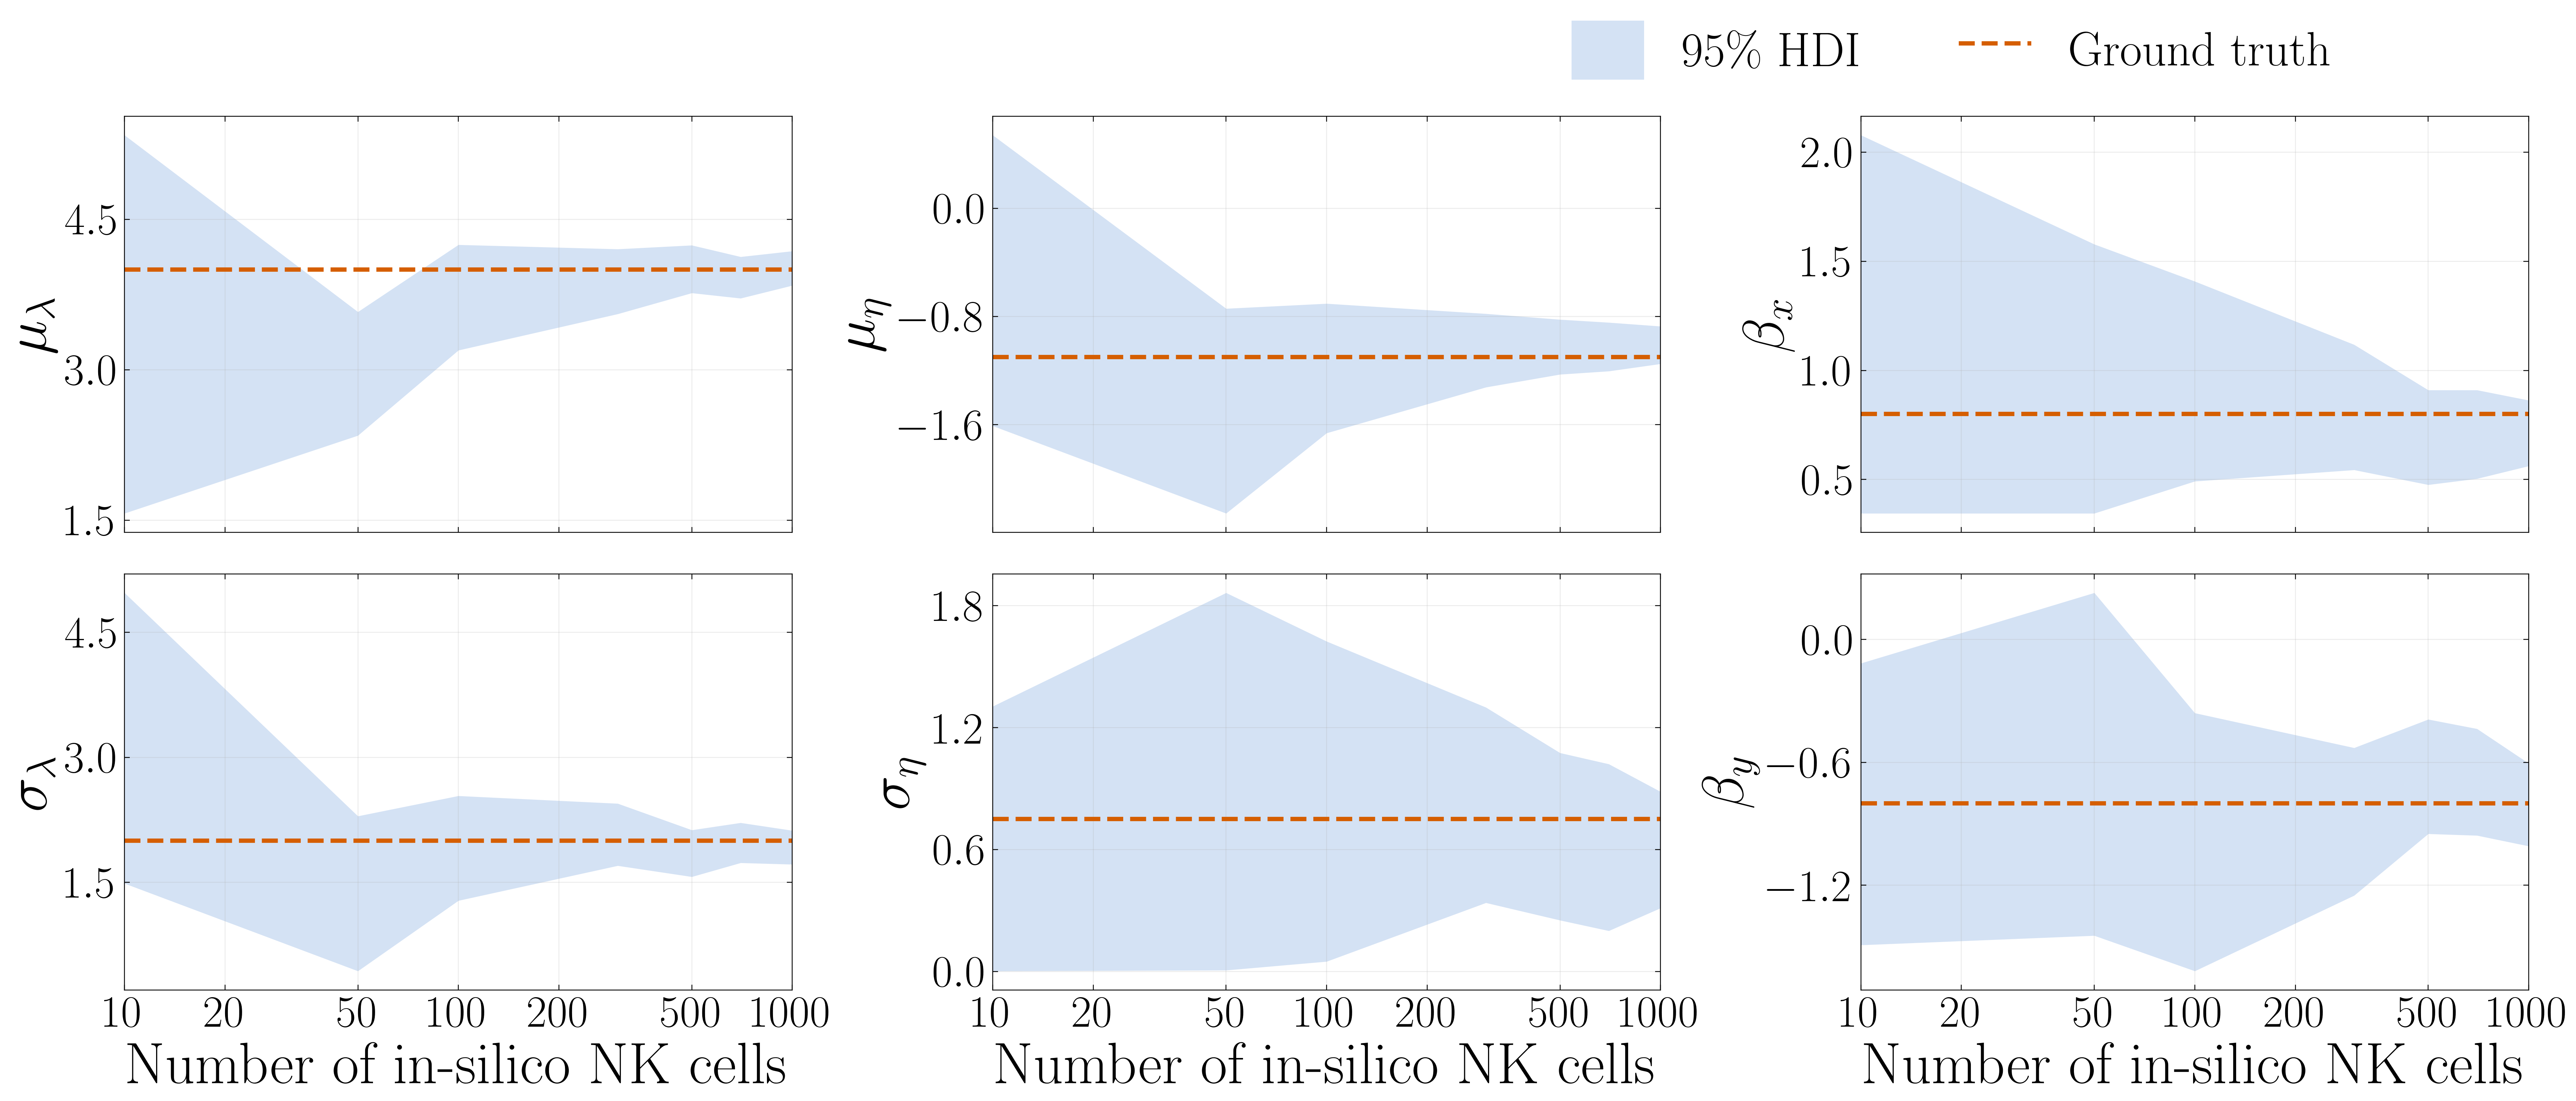

In [34]:
PARAMETERS = [
    "mu_lambda",
    "sigma_lambda",
    # "mu_p0",
    "mu_eta",
    "sigma_eta",
    "beta_x",
    "beta_y",
]

PARAM_LABELS = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    # "mu_p0": r"$\mu_{p_0}$",
    "mu_eta": r"$\mu_\eta$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_x$",
    "beta_y": r"$\beta_y$",
}

PLOT_PARAMETERS = [
    "mu_lambda", "mu_eta", "beta_x",
    "sigma_lambda", "sigma_eta", "beta_y",
]

LABEL_SIZE = 34
TICK_SIZE = 26
LEGEND_SIZE = 28
TICK_NBINS = 4
GROUND_TRUTH_COLOR = "#D55E00"
GROUND_TRUTH_LINESTYLE = "--"
GROUND_TRUTH_LINEWIDTH = 2.5
POSTERIOR_COLOR = "#1562C6"


def param_display_label(param: str) -> str:
    return PARAM_LABELS.get(param, param)


def sample_size_ticks(sample_sizes, xscale: str) -> list[int]:
    sizes = sorted(int(x) for x in sample_sizes)
    lo, hi = sizes[0], sizes[-1]

    if xscale == "log":
        ticks = []
        start_decade = int(np.floor(np.log10(lo)))
        end_decade = int(np.ceil(np.log10(hi)))
        for decade in range(start_decade, end_decade + 1):
            for multiplier in (1, 2, 5):
                tick = int(multiplier * (10 ** decade))
                if lo <= tick <= hi:
                    ticks.append(tick)
    else:
        locator = MaxNLocator(nbins=6, integer=True)
        ticks = [int(t) for t in locator.tick_values(lo, hi) if lo <= t <= hi]

    ticks.extend([lo, hi])
    return sorted(set(ticks))


def hdi_columns(summary: pd.DataFrame) -> tuple[str | None, str | None]:
    lower = next((col for col in summary.columns if col.startswith("hdi_") and col.endswith("2.5%")), None)
    upper = next((col for col in summary.columns if col.startswith("hdi_") and col.endswith("97.5%")), None)
    if lower is None or upper is None:
        hdi_cols = [col for col in summary.columns if col.startswith("hdi_")]
        if len(hdi_cols) >= 2:
            lower, upper = hdi_cols[0], hdi_cols[-1]
    return lower, upper


rows = []
logml_rows = []

for n_dir in sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.isdigit()], key=lambda p: int(p.name)):
    summary_path = n_dir / "posterior_summary_complex_smc.csv"
    true_path = n_dir / "true_parameters.csv"
    logml_path = n_dir / "log_marginal_likelihood_complex_smc.csv"
    if not summary_path.exists():
        continue

    summary = pd.read_csv(summary_path, index_col=0)
    true_params = pd.read_csv(true_path).iloc[0].to_dict()
    hdi_low, hdi_high = hdi_columns(summary)
    n_cell = int(n_dir.name)

    for param in PARAMETERS:
        if param not in summary.index:
            continue
        rows.append(
            {
                "n_cell": n_cell,
                "parameter": param,
                "mean": float(summary.loc[param, "mean"]),
                "hdi_low": float(summary.loc[param, hdi_low]) if hdi_low else np.nan,
                "hdi_high": float(summary.loc[param, hdi_high]) if hdi_high else np.nan,
                "true": float(true_params[param]),
            }
        )

    if logml_path.exists():
        logml = pd.read_csv(logml_path).iloc[0]
        logml_rows.append({"n_cell": n_cell, "logml": float(logml["logml"])})

posterior_long = pd.DataFrame(rows)
logml_df = pd.DataFrame(logml_rows).sort_values("n_cell")
sample_sizes = sorted(posterior_long["n_cell"].unique())


xscale = "log"

fig, axes = plt.subplots(
    2,
    3,
    figsize=(21, 9),
    dpi=350,
    sharex=True,
)
axes = axes.ravel()

for ax, param in zip(axes, PLOT_PARAMETERS):
    ax.set_facecolor("none")
    sub = posterior_long[posterior_long["parameter"] == param].sort_values("n_cell")
    if sub.empty:
        ax.axis("off")
        continue

    x = sub["n_cell"].to_numpy(dtype=float)
    lo = sub["hdi_low"].to_numpy(dtype=float)
    hi = sub["hdi_high"].to_numpy(dtype=float)
    true_value = float(sub["true"].iloc[0])

    ax.fill_between(
        x,
        lo,
        hi,
        color=POSTERIOR_COLOR,
        alpha=0.18,
        linewidth=0,
        label="95\% HDI",
    )

    ax.axhline(
        true_value,
        color=GROUND_TRUTH_COLOR,
        linestyle=GROUND_TRUTH_LINESTYLE,
        linewidth=GROUND_TRUTH_LINEWIDTH,
        label="Ground truth",
    )

    ax.set_ylabel(param_display_label(param), fontsize=LABEL_SIZE)
    ax.grid(alpha=0.25)
    ax.set_xscale(xscale)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.tick_params(axis="x", labelbottom=True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=TICK_NBINS))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.minorticks_off()
    ax.set_xlim(left=sample_sizes[0], right=sample_sizes[-1])
    

for ax in axes[:3]:
    ax.tick_params(axis="x", labelbottom=False)

for ax in axes[3:]:
    if ax.get_visible():
        ax.set_xlabel("Number of in-silico NK cells", fontsize=LABEL_SIZE)
        ax.tick_params(axis="x", labelbottom=True)

x_ticks = sample_size_ticks(sample_sizes, xscale)
for ax in axes:
    if ax.get_visible():
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(n) for n in x_ticks])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.92, 1.00),  # tune legend position here
    ncol=2,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.5,
    handleheight=1.5,
    labelspacing=0.6,
    columnspacing=2.0,
    borderpad=0.3,
)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.10,
    top=0.88,
    wspace=0.3,  # horizontal space between columns
    hspace=0.1,  # vertical space between rows
)

out_path = figure_dir / f"complex_model_parameter_recovery_{xscale}.svg"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
out_path

In [3]:
import arviz as az
import seaborn as sns
from matplotlib import gridspec
from matplotlib.ticker import NullLocator

comparison_sizes = [50, 500, 1000]

PARAM_XLIMS = {
    "mu_lambda": (2, 6),
    "sigma_lambda": (0, 4),
    "mu_p0": (0, 0.5),
    "sigma_eta": (0, 2),
    "beta_x": (-0.5, 1.8),
    "beta_y": (-1.8, 0.5),
}

PARAM_TICKS = {
    "mu_lambda": [2, 4, 6],
    "sigma_lambda": [0, 2, 4],
    "mu_p0": [0, 0.25, 0.5],
    "sigma_eta": [0, 1, 2],
    "beta_x": [0, 0.8, 1.6],
    "beta_y": [-1.6, -0.8, 0],
}

PARAM_TICKLABELS = {
    "mu_lambda": ["2", "4", "6"],
    "sigma_lambda": ["0", "2", "4"],
    "mu_p0": ["0", "0.25", "0.5"],
    "sigma_eta": ["0", "1", "2"],
    "beta_x": ["0", "0.8", "1.6"],
    "beta_y": ["-1.6", "-0.8", "0"],
}


def load_posterior(n: int):
    return az.from_netcdf(run_dir / str(n) / "posterior_complex_smc.nc")


def load_true_parameters(n: int) -> dict[str, float]:
    return pd.read_csv(run_dir / str(n) / "true_parameters.csv").iloc[0].to_dict()


def posterior_values(idata, param: str) -> np.ndarray:
    if param not in idata.posterior:
        return np.array([], dtype=float)

    vals = idata.posterior[param].stack(sample=("chain", "draw")).values.ravel()
    vals = np.asarray(vals, dtype=float)
    return vals[np.isfinite(vals)]


comparison_idatas = []
comparison_ground_truth = {}

for n in comparison_sizes:
    label = f"{n} cells"
    idata = load_posterior(n)
    truth = load_true_parameters(n)

    comparison_idatas.append((label, idata))
    comparison_ground_truth[label] = {
        param: float(truth[param])
        for param in PARAMETERS
        if param in truth
    }

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_1_complex/posterior_marginal_comparison_n50_n500_n1000_3x2.svg')

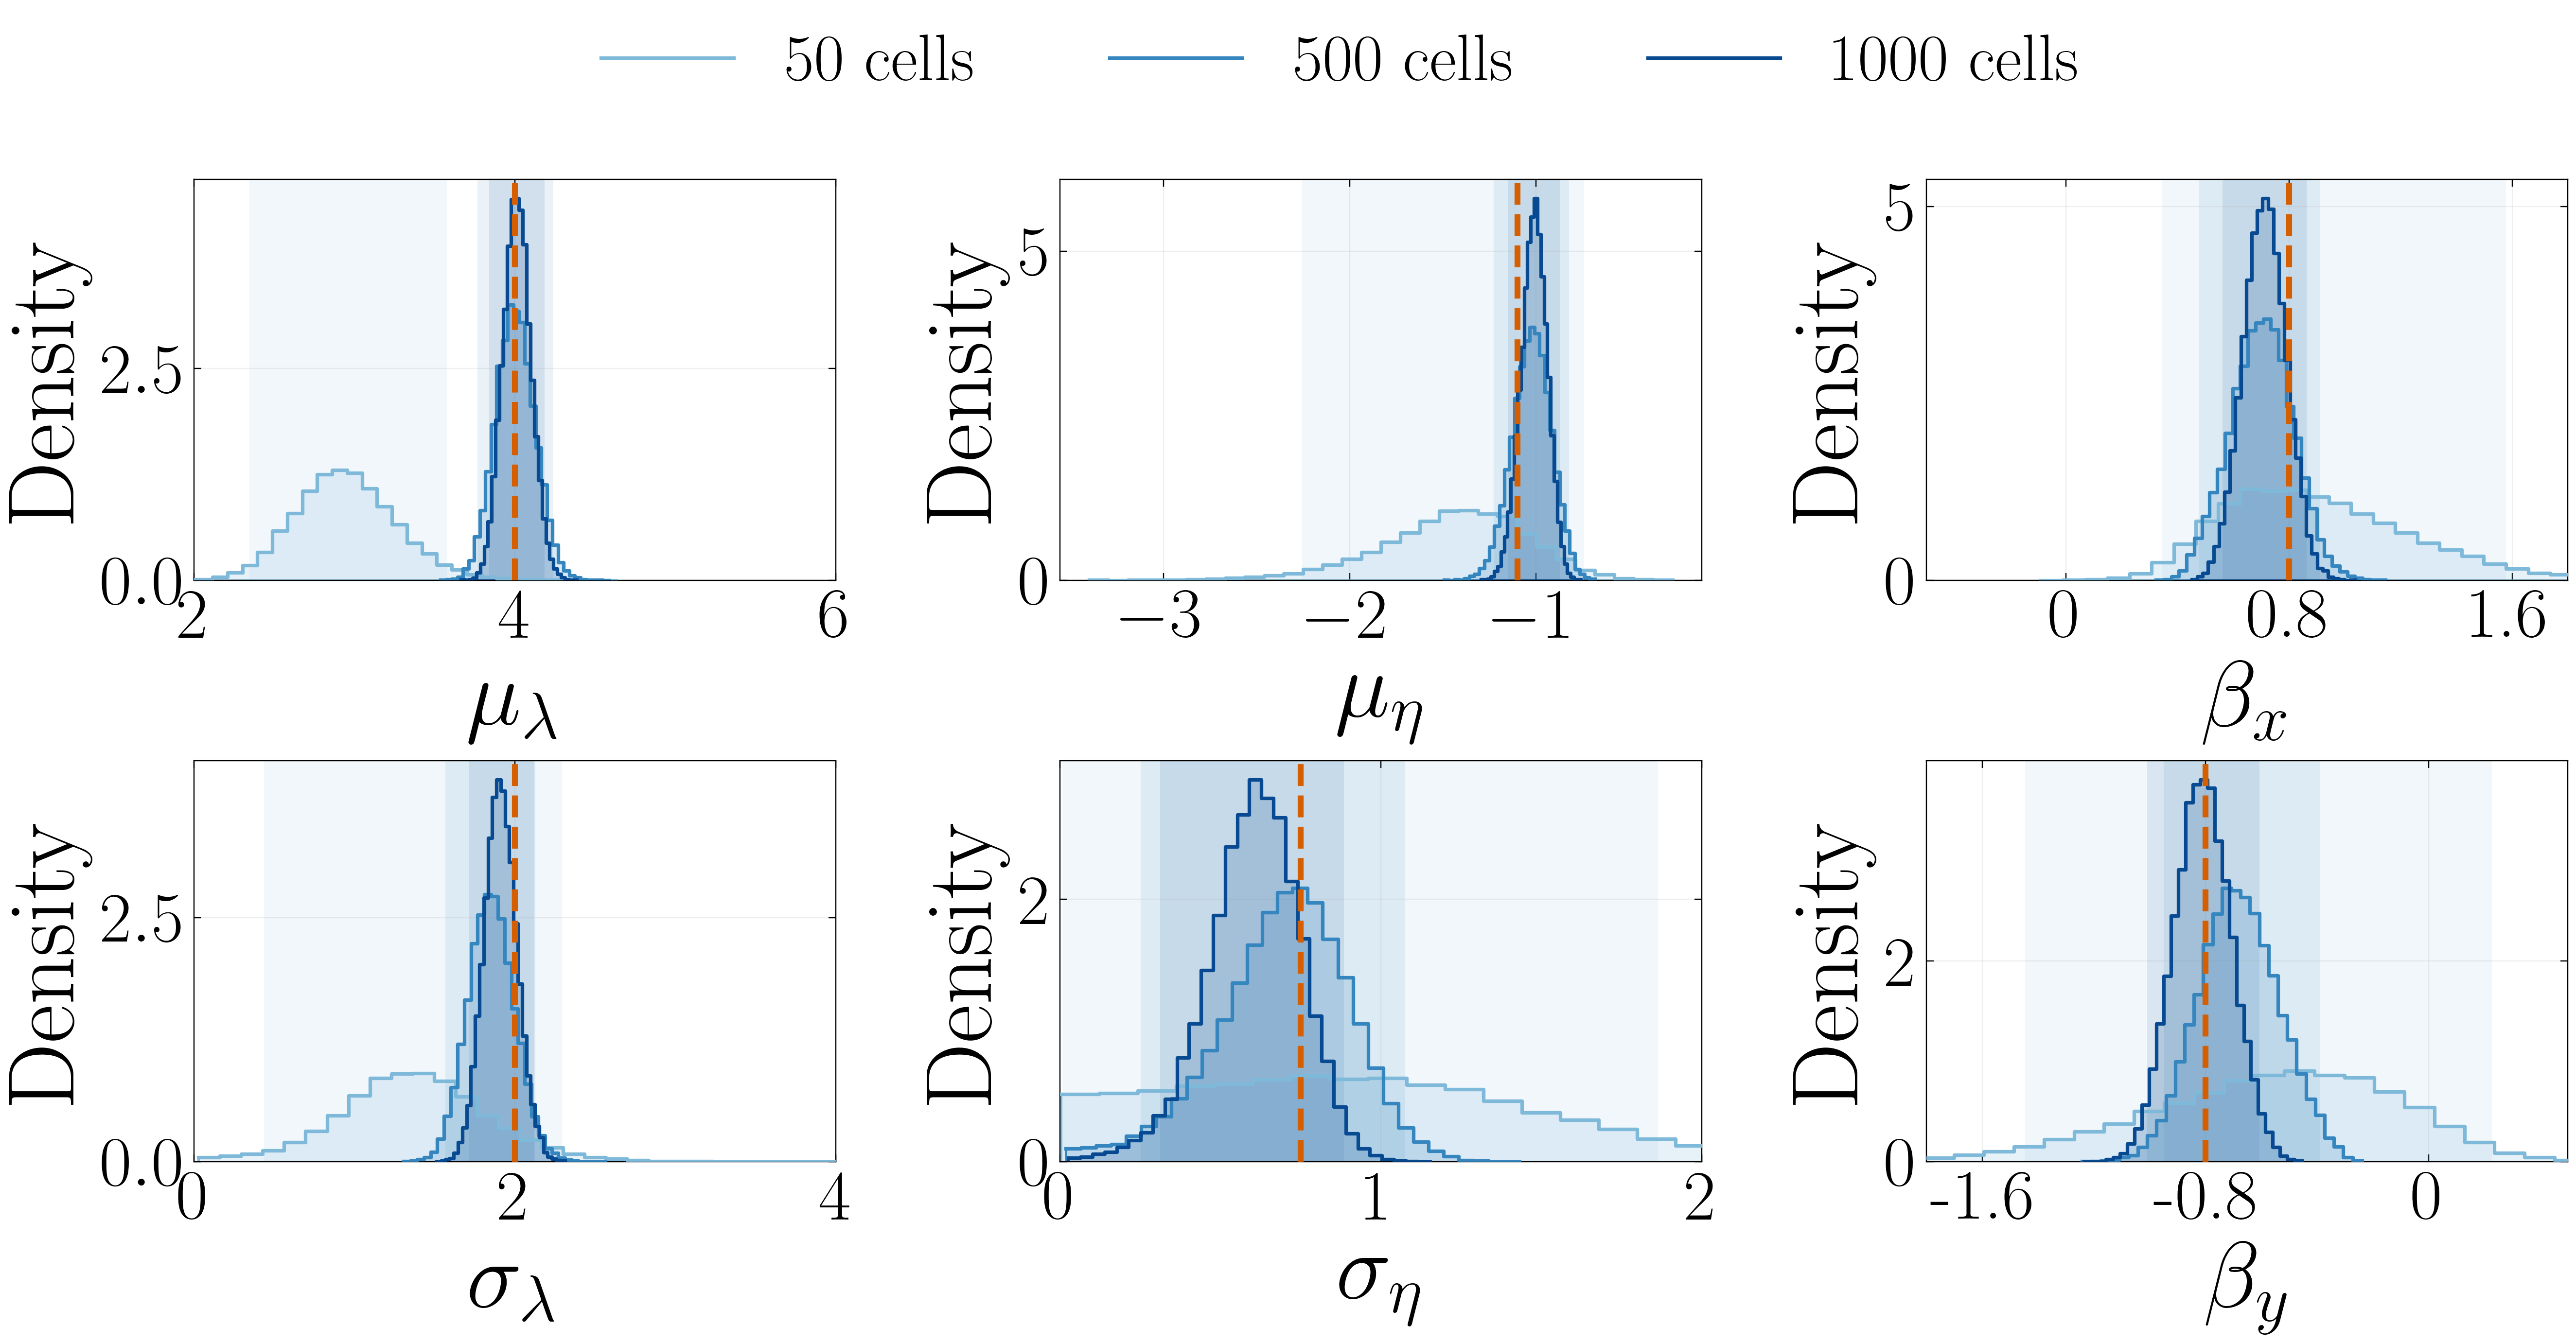

In [33]:
colors = plt.colormaps["Blues"](np.linspace(0.45, 0.9, len(comparison_idatas)))

PLOT_PARAMETERS = [
    "mu_lambda", "mu_eta", "beta_x",
    "sigma_lambda", "sigma_eta", "beta_y",
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 7.5),
    dpi=350,
)
axes = axes.ravel()

LABEL_SIZE = 40
TICK_SIZE = 30
LEGEND_SIZE = 28
HDI_PROB = 0.95

for ax, param in zip(axes, PLOT_PARAMETERS):
    ax.set_facecolor("none")

    for color, (label, idata) in zip(colors, comparison_idatas):
        vals = posterior_values(idata, param)
        if vals.size == 0:
            continue

        hdi_low, hdi_high = az.hdi(vals, hdi_prob=HDI_PROB)

        ax.axvspan(
            hdi_low,
            hdi_high,
            color=color,
            alpha=0.10,
            linewidth=0,
            zorder=0,
        )

        sns.histplot(
            vals,
            bins=30,
            stat="density",
            kde=False,
            ax=ax,
            color=color,
            alpha=0.18,
            element="step",
            fill=True,
            zorder=2,
        )

        sns.histplot(
            vals,
            bins=30,
            stat="density",
            kde=False,
            ax=ax,
            color=color,
            alpha=1.0,
            element="step",
            fill=False,
            linewidth=1.5,
            label=label,
            zorder=3,
        )

    truth_values = {
        comparison_ground_truth[label][param]
        for label, _idata in comparison_idatas
        if param in comparison_ground_truth[label]
    }

    for truth_value in truth_values:
        ax.axvline(
            truth_value,
            color=GROUND_TRUTH_COLOR,
            linestyle=GROUND_TRUTH_LINESTYLE,
            linewidth=GROUND_TRUTH_LINEWIDTH,
            zorder=4,
        )

    ax.set_xlabel(param_display_label(param), fontsize=LABEL_SIZE)
    ax.set_ylabel("Density", fontsize=LABEL_SIZE)
    ax.grid(alpha=0.2)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

    if param in PARAM_XLIMS:
        ax.set_xlim(*PARAM_XLIMS[param])

    if param in PARAM_TICKS:
        ax.set_xticks(PARAM_TICKS[param])
        ax.set_xticklabels(PARAM_TICKLABELS[param])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=len(comparison_idatas),
    frameon=False,
    fontsize=LEGEND_SIZE,
)

fig.subplots_adjust(
    wspace=0.35,
    hspace=0.45,
    top=0.88,
)

out_path = figure_dir / "posterior_marginal_comparison_n50_n500_n1000_3x2.svg"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
out_path

In [6]:
def apply_param_ticks(
    ax,
    *,
    xparam=None,
    yparam=None,
    param_ticks=None,
    param_ticklabels=None,
):
    if not param_ticks:
        return

    if xparam in param_ticks:
        ax.set_xticks(param_ticks[xparam])
        if param_ticklabels and xparam in param_ticklabels:
            ax.set_xticklabels(param_ticklabels[xparam])

    if yparam in param_ticks:
        ax.set_yticks(param_ticks[yparam])
        if param_ticklabels and yparam in param_ticklabels:
            ax.set_yticklabels(param_ticklabels[yparam])


def plot_posteriors_pair(
    idatas,
    *,
    parameters,
    ground_truth,
    parameter_display,
    save_path,
    xlims=None,
    param_ticks=None,
    param_ticklabels=None,
    cmap_name="Blues",
    seed=2026,
    sample_size=10_000,
):
    labels = [label for label, _idata in idatas]
    colors = plt.colormaps[cmap_name](np.linspace(0.45, 0.9, len(idatas)))
    rng = np.random.default_rng(seed)

    label_to_df = {}

    for label, idata in idatas:
        df = pd.DataFrame()
        for param in parameters:
            vals = posterior_values(idata, param)
            if vals.size > sample_size:
                vals = rng.choice(vals, size=sample_size, replace=False)
            if vals.size:
                df[param] = vals
        if not df.empty:
            label_to_df[label] = df

    npar = len(parameters)
    fig = plt.figure(figsize=(4 * npar, 4 * npar), dpi=350)
    fig.patch.set_alpha(0.0)

    gs = gridspec.GridSpec(npar, npar, wspace=0.38, hspace=0.38)
    gaxes = np.empty((npar, npar), dtype=object)

    for irow, rowpar in enumerate(parameters):
        for icol, colpar in enumerate(parameters):
            ax = plt.subplot(gs[irow, icol])
            gaxes[irow, icol] = ax
            ax.set_facecolor("none")
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())

            if icol > irow:
                ax.axis("off")
                continue

            for color, (label, df) in zip(colors, label_to_df.items()):
                if icol == irow:
                    vals = df[rowpar].dropna().values
                    sns.histplot(
                        vals,
                        bins=30,
                        stat="density",
                        kde=False,
                        ax=ax,
                        color=color,
                        alpha=0.18,
                        element="step",
                        fill=True,
                    )
                    sns.histplot(
                        vals,
                        bins=30,
                        stat="density",
                        kde=False,
                        ax=ax,
                        color=color,
                        alpha=1.0,
                        element="step",
                        fill=False,
                        linewidth=1.6,
                        label=label if irow == 0 else None,
                    )

                    if label in ground_truth and rowpar in ground_truth[label]:
                        ax.axvline(
                            ground_truth[label][rowpar],
                            color=GROUND_TRUTH_COLOR,
                            linestyle=GROUND_TRUTH_LINESTYLE,
                            linewidth=GROUND_TRUTH_LINEWIDTH,
                        )
                else:
                    sns.kdeplot(
                        x=df[colpar],
                        y=df[rowpar],
                        ax=ax,
                        fill=False,
                        color=color,
                        alpha=0.65,
                        levels=5,
                        linewidths=1.1,
                    )

                    if label in ground_truth:
                        gt = ground_truth[label]
                        if colpar in gt and rowpar in gt:
                            ax.axvline(
                                gt[colpar],
                                color=GROUND_TRUTH_COLOR,
                                linestyle=GROUND_TRUTH_LINESTYLE,
                                linewidth=GROUND_TRUTH_LINEWIDTH,
                            )
                            ax.axhline(
                                gt[rowpar],
                                color=GROUND_TRUTH_COLOR,
                                linestyle=GROUND_TRUTH_LINESTYLE,
                                linewidth=GROUND_TRUTH_LINEWIDTH,
                            )

            if icol == irow:
                ax.set_xlabel(parameter_display.get(rowpar, rowpar), fontsize=LABEL_SIZE)
                ax.set_ylabel("Density", fontsize=LABEL_SIZE)
                if xlims and rowpar in xlims:
                    ax.set_xlim(*xlims[rowpar])
                apply_param_ticks(
                    ax,
                    xparam=rowpar,
                    param_ticks=param_ticks,
                    param_ticklabels=param_ticklabels,
                )
            else:
                ax.set_xlabel(parameter_display.get(colpar, colpar), fontsize=LABEL_SIZE)
                ax.set_ylabel(parameter_display.get(rowpar, rowpar), fontsize=LABEL_SIZE)
                if xlims and colpar in xlims:
                    ax.set_xlim(*xlims[colpar])
                if xlims and rowpar in xlims:
                    ax.set_ylim(*xlims[rowpar])
                apply_param_ticks(
                    ax,
                    xparam=colpar,
                    yparam=rowpar,
                    param_ticks=param_ticks,
                    param_ticklabels=param_ticklabels,
                )

            ax.grid(alpha=0.25)
            ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)

    legend_items = {}
    for ax in gaxes.ravel():
        if ax is None:
            continue
        handles, leg_labels = ax.get_legend_handles_labels()
        for handle, leg_label in zip(handles, leg_labels):
            if leg_label and not leg_label.startswith("_"):
                legend_items.setdefault(leg_label, handle)

    if legend_items:
        fig.legend(
            list(legend_items.values()),
            list(legend_items.keys()),
            loc="upper right",
            bbox_to_anchor=(0.88, 0.88),
            frameon=False,
            fontsize=LEGEND_SIZE,
        )

    save_path = Path(save_path)
    fig.savefig(save_path.with_suffix(".svg"), bbox_inches="tight", transparent=True)
    plt.close(fig)

    return save_path.with_suffix(".svg")


plot_posteriors_pair(
    comparison_idatas,
    parameters=PARAMETERS,
    ground_truth=comparison_ground_truth,
    parameter_display=PARAM_LABELS,
    xlims=PARAM_XLIMS,
    save_path=figure_dir / "posterior_pair_comparison_n50_n500_n1000",
    cmap_name="Blues",
    seed=2026,
    param_ticks=PARAM_TICKS,
    param_ticklabels=PARAM_TICKLABELS,
)

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_1_complex/posterior_pair_comparison_n50_n500_n1000.svg')